In [1]:
import matplotlib.pyplot as plt
import numpy as np

from piwavelet.transforms import xwt
from piwavelet.plotting.cross_wavelet import (
    CrossWaveletResult,
    plot_cross_wavelet,
)

In [2]:
# ----------------------------------------------------------------------
# synthetic signals
# ----------------------------------------------------------------------

dt = 0.01

time = np.arange(
    0,
    20,
    dt,
)

# ----------------------------------------------------------------------
# signal 1
# ----------------------------------------------------------------------

x = (
    np.sin(2 * np.pi * 5 * time)
    + 0.5 * np.sin(2 * np.pi * 12 * time)
)

# transient burst
x += (
    np.exp(
        -0.5 * ((time - 10) / 1.0) ** 2
    )
    * np.sin(2 * np.pi * 20 * time)
)

# ----------------------------------------------------------------------
# signal 2
# ----------------------------------------------------------------------

phase_shift = np.pi / 4

y = (
    np.sin(
        2 * np.pi * 5 * time
        + phase_shift
    )
    + 0.5 * np.sin(
        2 * np.pi * 12 * time
    )
)

y += (
    np.exp(
        -0.5 * ((time - 10) / 1.0) ** 2
    )
    * np.sin(
        2 * np.pi * 20 * time
        + np.pi / 2
    )
)

# noise
x += 0.2 * np.random.randn(
    time.size
)

y += 0.2 * np.random.randn(
    time.size
)

In [3]:
# ----------------------------------------------------------------------
# compute cross wavelet transform
# ----------------------------------------------------------------------

xwt_result = xwt(
    x,
    y,
    dt=dt,
)

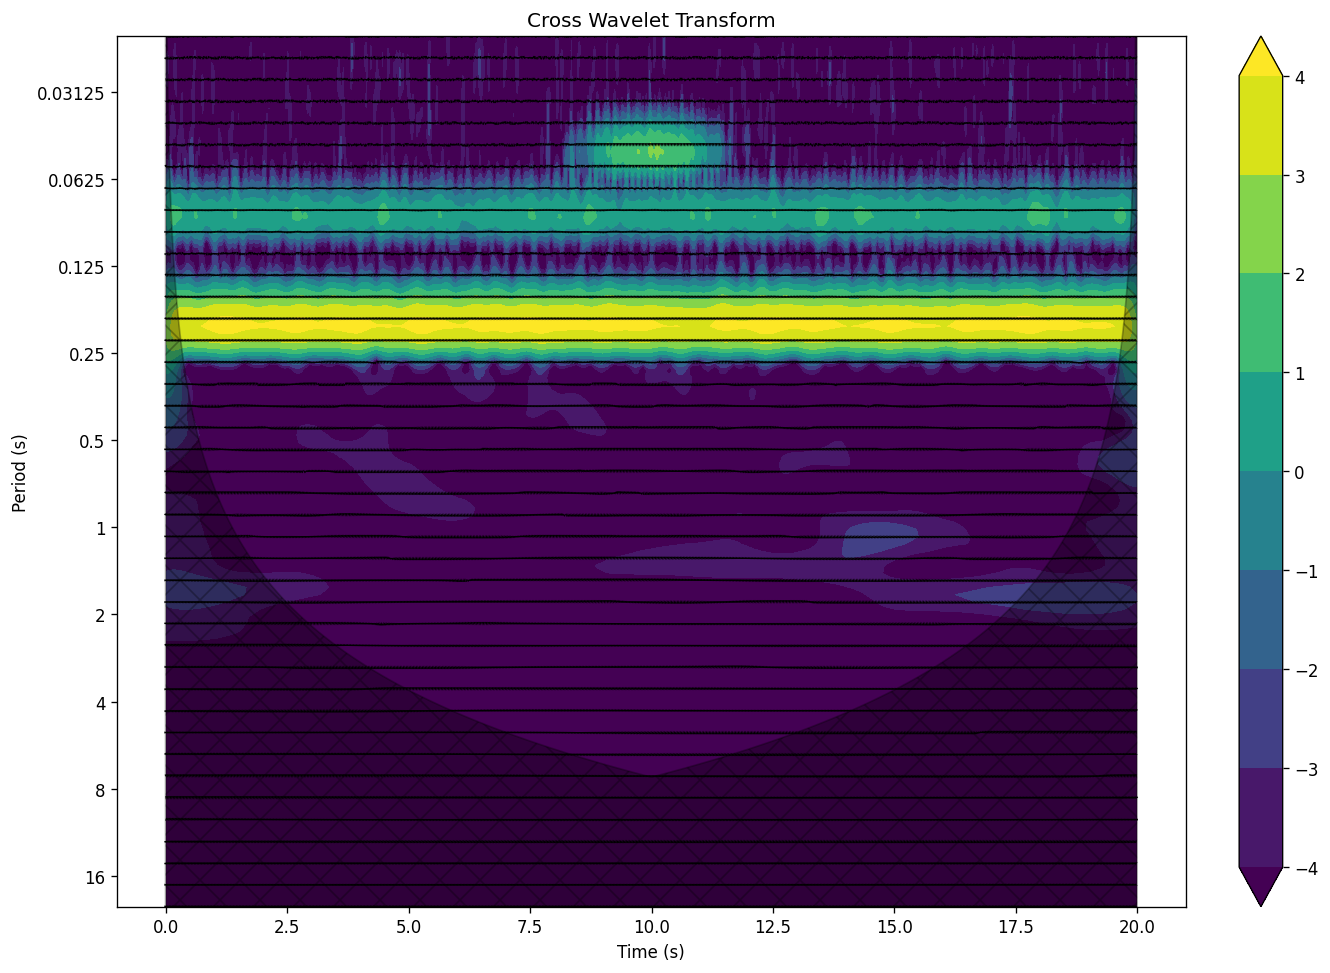

In [4]:

# ----------------------------------------------------------------------
# plotting result
# ----------------------------------------------------------------------

plot_result = CrossWaveletResult(
    time=time,
    cross_wavelet=xwt_result.cross_wavelet,
    periods=xwt_result.periods,
    frequencies=xwt_result.frequencies,
    scales=xwt_result.scales,
    coi=xwt_result.coi,
    significance=np.ones_like(
        xwt_result.power,
        dtype=np.float64,
    ),
    phase=xwt_result.phase,
)

# ----------------------------------------------------------------------
# plot
# ----------------------------------------------------------------------

fig = plot_cross_wavelet(
    plot_result,
    title="Cross Wavelet Transform",
    units="s",
    show_phase=True,
)

plt.show()